# Project B - Analysis of the population of Madagascar with food problems
**TEAM MEMBERS AND DATASET**

Dataset: WFP HungerMap - Madagascar
Members:
- Marya LATIF 
- Raphaël MARQUES ARAUJO
- Faty LO
- François-Louis Legland
- Philippine LHOMME

## Import libraries

In [102]:
#!pip install pandas
#!pip install mlxtend
#!pip install plotly
#!pip install --upgrade nbformat
#!pip install prophet
#!pip install mlxtend

In [103]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.impute import KNNImputer
import statistics as st
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from prophet import Prophet
from sklearn.cluster import OPTICS
from sklearn.preprocessing import MinMaxScaler
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules

## Remark
In the first part, we will clean and analyse the dataset using statistics and visualisations. Each sub-section will be justified and interpreted if necessary.
In the second part, we will call all the functions we need to create a dashboard that will bring together all the visualisations made previously.

Let's go !

### Dataset exploration

In [104]:
def load_data(file_path):
    """
    Load CSV data and skip description row
    Input: file_path, path to CSV file
    Output: dataframe
    """
    print("======= Load & Display Data =======\n")
    
    # Read CSV and skip the second row (index 1)
    df = pd.read_csv(file_path)
    display(df.head())

    print("\n===skip description row===")
    df = pd.read_csv(file_path, skiprows=[1])
    display(df.head())
    
    # Display shape
    print(f"\n Data shape: {df.shape}")
    
    print("\n======= Summary statistics =======\n")
    display(df.describe())  
    
    print("\n======= DataFrame info =======\n")
    df.info()  
    
    return df

file_path = 'wfp-hungermap-data-for-mdg.csv'
df = load_data(file_path)

======= Load & Display Data =======



,countrycode,countryname,adminone,adminlevel,population,date,datatype,fcs people,fcs prevalence,rcsi people,rcsi prevalence,health access people,health access prevalence,market access people,market access prevalence
0,#country+code,#country+name,#adm1+name,#meta+adminlevel,#population+total,#date,#data+type,#population+fcs,#indicator+fcs+prevalence,#population+rcsi,#indicator+rcsi+prevalence,#population+health_access,#indicator+health_access+prevalence,#population+market_access,#indicator+market_access+prevalence
1,MDG,Madagascar,NaN,national,NaN,2024-03-04,SURVEY,8456947,0.32215332807656305,7816509,0.2977569119407755,2155430,0.08210751797908643,3180077,0.12113974014886676
2,MDG,Madagascar,NaN,national,NaN,2024-03-03,SURVEY,8604019,0.32775579126651516,7708249,0.2936329211224791,2185552,0.08325496662992705,3222276,0.1227472490461335
3,MDG,Madagascar,NaN,national,NaN,2024-03-02,SURVEY,8654571,0.3296814856147151,7845463,0.29885986642190426,2227397,0.08484898329823913,3284548,0.12511939962610666
4,MDG,Madagascar,NaN,national,NaN,2024-03-01,SURVEY,8597649,0.327513141248951,7748351,0.2951605462736907,2175090,0.08285642813079001,3330646,0.12687541988738874



===skip description row===


,countrycode,countryname,adminone,adminlevel,population,date,datatype,fcs people,fcs prevalence,rcsi people,rcsi prevalence,health access people,health access prevalence,market access people,market access prevalence
0,MDG,Madagascar,NaN,national,NaN,2024-03-04,SURVEY,8456947,0.322153,7816509,0.297757,2155430,0.082108,3180077,0.121140
1,MDG,Madagascar,NaN,national,NaN,2024-03-03,SURVEY,8604019,0.327756,7708249,0.293633,2185552,0.083255,3222276,0.122747
2,MDG,Madagascar,NaN,national,NaN,2024-03-02,SURVEY,8654571,0.329681,7845463,0.298860,2227397,0.084849,3284548,0.125119
3,MDG,Madagascar,NaN,national,NaN,2024-03-01,SURVEY,8597649,0.327513,7748351,0.295161,2175090,0.082856,3330646,0.126875
4,MDG,Madagascar,NaN,national,NaN,2024-02-29,SURVEY,8578497,0.326784,7827478,0.298175,2126254,0.080996,3322466,0.126564



 Data shape: (1381, 15)

======= Summary statistics =======



,population,fcs people,fcs prevalence,rcsi people,rcsi prevalence,health access people,health access prevalence,market access people,market access prevalence
count,1.320000e+03,1.381000e+03,1381.000000,1.381000e+03,1381.000000,1.381000e+03,1381.000000,1.381000e+03,1381.000000
mean,1.193241e+06,7.608201e+05,0.325185,6.230508e+05,0.275245,2.001989e+05,0.082179,2.809448e+05,0.124619
std,7.698637e+05,1.725474e+06,0.099883,1.414499e+06,0.068609,4.575622e+05,0.031464,6.369537e+05,0.055015
min,3.480530e+05,4.960400e+04,0.126463,8.473300e+04,0.081430,4.938000e+03,0.012154,2.163200e+04,0.036112
25%,8.074180e+05,1.765190e+05,0.240862,1.763340e+05,0.229417,6.330500e+04,0.055626,6.821600e+04,0.081739
50%,1.020608e+06,3.707970e+05,0.322752,2.850400e+05,0.273562,8.345200e+04,0.086711,1.295850e+05,0.116571
75%,1.498769e+06,5.642620e+05,0.413205,4.093540e+05,0.300311,1.289870e+05,0.105396,2.172740e+05,0.146769
max,4.024795e+06,9.503583e+06,0.548083,8.031839e+06,0.535283,2.573170e+06,0.184598,3.578953e+06,0.345412



======= DataFrame info =======

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1381 entries, 0 to 1380
Data columns (total 15 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   countrycode               1381 non-null   object 
 1   countryname               1381 non-null   object 
 2   adminone                  1320 non-null   object 
 3   adminlevel                1381 non-null   object 
 4   population                1320 non-null   float64
 5   date                      1381 non-null   object 
 6   datatype                  1381 non-null   object 
 7   fcs people                1381 non-null   int64  
 8   fcs prevalence            1381 non-null   float64
 9   rcsi people               1381 non-null   int64  
 10  rcsi prevalence           1381 non-null   float64
 11  health access people      1381 non-null   int64  
 12  health access prevalence  1381 non-null   float64
 13  market access people      1381

- About columns : countrycode and countryname have a unique value, we are studying data from a single country = Madagascar. Same for datatype, it's always a SURVEY.
- About data infos : We can see that almost all columns are non-zero, except for adminone and population. 
All types ar object, we going to adapt the type automatically

In [105]:
def convert_types(df):
    """
    Convert columns to appropriate data types and remove unnecessary columns.
    
    - Remove unnecessary columns (countrycode, datatype, countryname)
    - Automatically detect text columns
    - Convert all other columns to numeric
    """
    # Remove unnecessary columns
    for col in ['countrycode', 'datatype', 'countryname']:
        if col in df.columns:
            df.drop(columns=[col], inplace=True)
    
    # Automatically detect text columns (dtype = object)
    text_cols = df.select_dtypes(include=['object']).columns.tolist()
    
    # Identify numeric columns (all except detected text columns)
    numeric_cols = [col for col in df.columns if col not in text_cols]
    
    # Convert numeric columns to numeric type (invalid values become NaN)
    df[numeric_cols] = df[numeric_cols].apply(pd.to_numeric, errors='coerce')
    
    return df
convert_types(df)

,adminone,adminlevel,population,date,fcs people,fcs prevalence,rcsi people,rcsi prevalence,health access people,health access prevalence,market access people,market access prevalence
0,NaN,national,NaN,2024-03-04,8456947,0.322153,7816509,0.297757,2155430,0.082108,3180077,0.121140
1,NaN,national,NaN,2024-03-03,8604019,0.327756,7708249,0.293633,2185552,0.083255,3222276,0.122747
2,NaN,national,NaN,2024-03-02,8654571,0.329681,7845463,0.298860,2227397,0.084849,3284548,0.125119
3,NaN,national,NaN,2024-03-01,8597649,0.327513,7748351,0.295161,2175090,0.082856,3330646,0.126875
4,NaN,national,NaN,2024-02-29,8578497,0.326784,7827478,0.298175,2126254,0.080996,3322466,0.126564
...,...,...,...,...,...,...,...,...,...,...,...,...
1376,Menabe,subnational,711639.0,2024-01-05,99807,0.140249,178358,0.250630,71084,0.099888,91533,0.128623
1377,Sava,subnational,1178796.0,2024-01-05,477003,0.404653,253350,0.214923,158273,0.134267,144382,0.122483
1378,Sofia,subnational,1498769.0,2024-01-05,468533,0.312612,336681,0.224638,99133,0.066143,229278,0.152978
1379,Vakinankaratra,subnational,2167330.0,2024-01-05,891656,0.411408,662316,0.305591,229429,0.105858,327763,0.151229


### NaN Managment

In [106]:
def check_missing_values(df):
    """
    Check missing values in the entire DataFrame.
    
    Parameters:
        df (DataFrame): The dataset
    
    Returns:
        DataFrame: Summary of missing values and their percentage
    """
    # Count missing values per column
    missing_count = df.isna().sum()
    
    # Calculate percentage of missing values
    missing_percent = (missing_count / len(df)) * 100
    
    # Combine into a DataFrame for better readability
    missing_summary = pd.DataFrame({
        'Missing Values': missing_count,
        'Percentage (%)': missing_percent.round(2)
    })
    
    # Print results
    print("Missing values summary:\n", missing_summary)
    
    return missing_summary
summary = check_missing_values(df)

Missing values summary:
                           Missing Values  Percentage (%)
adminone                              61            4.42
adminlevel                             0            0.00
population                            61            4.42
date                                   0            0.00
fcs people                             0            0.00
fcs prevalence                         0            0.00
rcsi people                            0            0.00
rcsi prevalence                        0            0.00
health access people                   0            0.00
health access prevalence               0            0.00
market access people                   0            0.00
market access prevalence               0            0.00


We note something interesting: since fcs people represents the number of people suffering from insufficient food consumption, and fcs prevalence represents the proportion of the population affected, we can directly deduce the population using these two quantities.

Indeed, by definition:
$$
fcs_{prevalence}
=
\frac{fcs_{people}}{population}
$$

so

$$
{population}
=
\frac{fcs_{people}}{fcs_{prevalence}}
$$

In [107]:
def compute_population(fcs_people, fcs_prevalence):
    """
    Calculate population from FCS data
    Formula: population = fcs_people / fcs_prevalence
    Input: fcs_people (float), fcs_prevalence (float)
    Output: population (float)
    """
    return fcs_people / fcs_prevalence
    
def fulfill_population(df):
    """
    Fill missing population values using FCS formula
    Input: df (dataframe)
    Output: dataframe with filled population column
    """
    mask = df["population"].isna()
    df.loc[mask, "population"] = compute_population(
        df.loc[mask, "fcs people"],
        df.loc[mask, "fcs prevalence"]
    )
    display(df.isnull().sum())
    return df
df=fulfill_population(df)

adminone                    61
adminlevel                   0
population                   0
date                         0
fcs people                   0
fcs prevalence               0
rcsi people                  0
rcsi prevalence              0
health access people         0
health access prevalence     0
market access people         0
market access prevalence     0
dtype: int64

In [108]:
df.head()

,adminone,adminlevel,population,date,fcs people,fcs prevalence,rcsi people,rcsi prevalence,health access people,health access prevalence,market access people,market access prevalence
0,NaN,national,2.625131e+07,2024-03-04,8456947,0.322153,7816509,0.297757,2155430,0.082108,3180077,0.121140
1,NaN,national,2.625131e+07,2024-03-03,8604019,0.327756,7708249,0.293633,2185552,0.083255,3222276,0.122747
2,NaN,national,2.625131e+07,2024-03-02,8654571,0.329681,7845463,0.298860,2227397,0.084849,3284548,0.125119
3,NaN,national,2.625131e+07,2024-03-01,8597649,0.327513,7748351,0.295161,2175090,0.082856,3330646,0.126875
4,NaN,national,2.625131e+07,2024-02-29,8578497,0.326784,7827478,0.298175,2126254,0.080996,3322466,0.126564


We can see that nothing has changed, so the errors were handled correctly during the conversion.

For numerical columns, we are going to use KNNImputer.

In [109]:
def replace_NaN(df, columns):
    """
    Replace NaN values using KNN Imputer (4 neighbors)
    Input: df (dataframe), columns (list) - columns to impute
    Output: dataframe without NaN in specified columns
    """
    imputer = KNNImputer(n_neighbors=4, weights='uniform')
    df_no_nan = imputer.fit_transform(df[columns])
    df[columns] = pd.DataFrame(df_no_nan, columns=columns)
    return df
df = replace_NaN(df, ['population'])
df.isna().sum()

adminone                    61
adminlevel                   0
population                   0
date                         0
fcs people                   0
fcs prevalence               0
rcsi people                  0
rcsi prevalence              0
health access people         0
health access prevalence     0
market access people         0
market access prevalence     0
dtype: int64

**What KNNImputer does:** For each missing value in a row, the algorithm calculates the distances (default nan_euclidean) to the other rows, ignoring NaNs, selects the 4 closest ones, and then replaces the value with the simple average of those neighbours in that column. The “uniform” weights mean that all neighbours contribute equally, without weighting by distance.

### Using a modified Z-Score transformation for outlier detection

In [110]:
def mad_z_score(tab):
    """
    Detect outliers using Modified Z-Score (MAD method)
    Input: tab (array) - values to check
    Output: list of outlier values
    """
    outliers = []
    mad = st.median([abs(val - st.median(tab)) for val in tab])
    for val in tab:
        if mad == 0:
            m = 0
        else:
            m = (0.6745 * (val - st.median(tab))) / mad
        if m > 3.5:
            outliers.append(val)
    return outliers

**MAD Z-Score (Modified Z-Score)**

What it does: Detects outliers using the median and MAD (Median Absolute Deviation) instead of the mean and standard deviation.

$$
    Modified-Z-Score = 0.6745 × \frac{x - median}{median(|x_i - median(x)|)}
$$

Why it's interesting:
- Robust to outliers: The median and MAD are not influenced by extreme values (unlike the mean/standard deviation of the classic Z-score)
- No bias: Outliers themselves do not skew the detection calculation
- Better accuracy: Avoids false negatives in asymmetric data


In [111]:
numeric_cols = df.select_dtypes(include=['number']).columns.tolist()
for col in numeric_cols:
    outliers = mad_z_score(df[col])
    print(f"Outliers for {col} ({len(outliers)}): ", outliers)

Outliers for population (121):  [26251310.363586005, 26251310.36358601, 26251310.363586, 26251310.000000004, 26251310.0, 26251310.000000004, 26251310.0, 26251309.0389, 26251311.527185, 26251310.0, 26251310.0, 26251310.0, 26251310.000000004, 26251310.0, 26251310.000000004, 26251310.000000004, 26251310.000000004, 26251310.000000004, 26251310.0, 26251310.0, 26251310.000000004, 26251310.000000004, 26251310.000000004, 26251310.0, 26251310.0, 26251310.0, 26251310.000000007, 26251310.000000004, 26251310.000000007, 26251310.000000007, 26251310.0, 26251310.0, 26251310.532714, 26251309.651947003, 26251309.651947003, 26251310.0, 26251310.000000004, 26251310.000000004, 26251310.0, 26251310.0, 26251310.000000004, 26251310.000000004, 26251310.0, 26251310.0, 26251310.000000007, 26251310.000000004, 26251310.000000004, 26251310.841329, 26251310.000000004, 26251311.582561005, 26251310.000000007, 26251310.0, 26251310.000000004, 26251310.0, 26251309.999999996, 26251310.0, 26251310.000000004, 26251310.0, 2

- This seems to be a lot. We can see many values close to each other, which is not necessarily an outlier.

## Feature selection
| Colonne                | Description courte                                                      |
|------------------------|------------------------------------------------------------------------|
| countrycode            | Country code (often an ISO code or standard country code)       |
| countryname            | Full name of the country                                                    |
| adminone               | Region name       |
| adminlevel             | Level of region       |
| population             | Local population     |
| date                   | Date of data           |
| datatype               | Data type (nature of the indicators measured)                       |
| fcs people             | Number of people with a poor FCS (food consumption score), i.e. the number of people vulnerable to hunger  |
| fcs prevalence         | Proportion of the population affected by FCS                                  |
| rcsi people            | Number of people affected by the ‘RCSI’ (may be Reduced Coping Strategy Index or another indicator) |
| rcsi prevalence        | Prevalence or proportion related to RCSI                                 |
| health access people   | Number of people with access to healthcare                      |
| health access prevalence| Prevalence or proportion of access to healthcare                 |
| market access people   | Number of people with access to markets                            |
| market access prevalence| Prevalence or proportion of market access                        |


### Let's display the correlation matrix to see which columns are relevant.

,population,fcs people,fcs prevalence,rcsi people,rcsi prevalence,health access people,health access prevalence,market access people,market access prevalence
population,1.000000,0.997302,0.024771,0.995490,-0.028115,0.995774,0.068317,0.993494,-0.019877
fcs people,0.997302,1.000000,0.084795,0.995377,0.005212,0.993882,0.080437,0.993977,0.008891
fcs prevalence,0.024771,0.084795,1.000000,0.052568,0.530508,0.039097,0.300384,0.067587,0.463501
rcsi people,0.995490,0.995377,0.052568,1.000000,0.034525,0.989731,0.067049,0.993047,0.007687
rcsi prevalence,-0.028115,0.005212,0.530508,0.034525,1.000000,-0.029332,0.083687,0.020907,0.472142
health access people,0.995774,0.993882,0.039097,0.989731,-0.029332,1.000000,0.138498,0.988708,-0.006796
health access prevalence,0.068317,0.080437,0.300384,0.067049,0.083687,0.138498,1.000000,0.084380,0.336138
market access people,0.993494,0.993977,0.067587,0.993047,0.020907,0.988708,0.084380,1.000000,0.073520
market access prevalence,-0.019877,0.008891,0.463501,0.007687,0.472142,-0.006796,0.336138,0.073520,1.000000


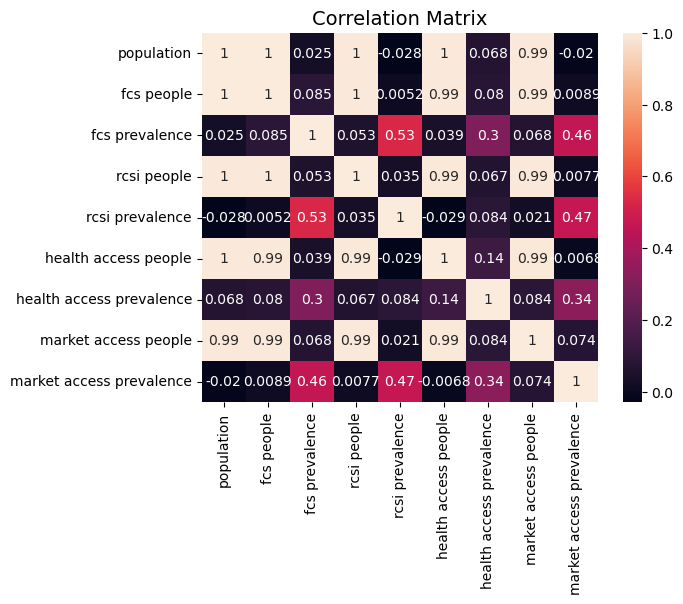

In [112]:
def plot_correlation_matrix(df):
    """
    Display correlation matrix heatmap for all numeric columns in the DataFrame.
    
    Input:
        df (DataFrame): The dataset
    Output:
        None (displays plot)
    """
    # Automatically select numeric columns
    numeric_cols = df.select_dtypes(include=['number']).columns.tolist()
    
    # Compute correlation matrix
    corr_matrix = df[numeric_cols].corr()
    display(corr_matrix)
    
    # Plot heatmap
    sns.heatmap(corr_matrix, annot=True)
    plt.title("Correlation Matrix", fontsize=14)
    plt.show()
plot_correlation_matrix(df)

#### Feature Selection - Decision

**Correlation Analysis Result**
The correlation matrix revealed that all `*_people` columns are highly correlated (r=0.99):
- `fcs people`
- `rcsi people`
- `health access people`
- `market access people`

**potential Decision**
We chose to KEEP all 4 columns despite high correlation for the following reasons:

1. Dashboard flexibility: Allows users to select which indicator to visualize
2. Comparative analysis: Enables side-by-side comparison of indicators
3. Interpretability: Each indicator has distinct policy meaning:
   - `fcs people`: Food consumption issues
   - `rcsi people`: Coping strategies usage
   - `health access people`: Healthcare access barriers
   - `market access people`: Market access barriers

4. Statistical consideration : While correlated, they measure slightly different aspects of vulnerability


**Recommendation**
Keep only one `*_people` variable and remove the other 3

Keep all `*_prevalence` variables:
- Moderate correlations are acceptable (0.34-0.53)

Keep `population`:
- Low correlations with other variables (<0.3)
- Independent information

### Trade-off
- Advantage: Richer analysis and visualizations
- Disadvantage: Potential multicollinearity in predictive models

**Note:** For machine learning models, we would use only `fcs people` to avoid multicollinearity.

### Let's now build some visualization to get some insights from the data

We convert the dates into the write format

In [113]:
def transform_datetime(df, date_col='date'):
    """
    Convert date column to datetime format
    Input: df (dataframe), date_col (str) - name of date column
    Output: dataframe with datetime column
    """
    df[date_col] = pd.to_datetime(df[date_col])
    return df
df=transform_datetime(df)
print(df["date"].dtype)

datetime64[ns]


In [114]:
df["date"].min()

Timestamp('2023-12-04 00:00:00')

We notice that we have an isolated date

In [115]:
def drop_outliers(df, column, outliers):
    """
    Remove outlier rows from dataframe
    Input: df (dataframe), column (str), outliers (list) - values to remove
    Output: dataframe without outliers
    """
    mask = df[column].isin(outliers)
    return df[~mask]


df = drop_outliers(df, "date", ["2023-12-04 00:00:00"])
df.head()

/var/folders/jc/0rdgc11d06dgm3sng453_7yr0000gn/T/ipykernel_35292/2759168297.py:7: FutureWarning:

The behavior of 'isin' with dtype=datetime64[ns] and castable values (e.g. strings) is deprecated. In a future version, these will not be considered matching by isin. Explicitly cast to the appropriate dtype before calling isin instead.



,adminone,adminlevel,population,date,fcs people,fcs prevalence,rcsi people,rcsi prevalence,health access people,health access prevalence,market access people,market access prevalence
0,NaN,national,2.625131e+07,2024-03-04,8456947,0.322153,7816509,0.297757,2155430,0.082108,3180077,0.121140
1,NaN,national,2.625131e+07,2024-03-03,8604019,0.327756,7708249,0.293633,2185552,0.083255,3222276,0.122747
2,NaN,national,2.625131e+07,2024-03-02,8654571,0.329681,7845463,0.298860,2227397,0.084849,3284548,0.125119
3,NaN,national,2.625131e+07,2024-03-01,8597649,0.327513,7748351,0.295161,2175090,0.082856,3330646,0.126875
4,NaN,national,2.625131e+07,2024-02-29,8578497,0.326784,7827478,0.298175,2126254,0.080996,3322466,0.126564


We are removing this isolated date to avoid problems with certain visuals. In addition, we will be able to focus solely on the year 2024.

In [116]:
df.isna().sum()

adminone                    60
adminlevel                   0
population                   0
date                         0
fcs people                   0
fcs prevalence               0
rcsi people                  0
rcsi prevalence              0
health access people         0
health access prevalence     0
market access people         0
market access prevalence     0
dtype: int64

In [117]:
df.dropna(inplace=True)
df.head()

/var/folders/jc/0rdgc11d06dgm3sng453_7yr0000gn/T/ipykernel_35292/3523028469.py:1: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



,adminone,adminlevel,population,date,fcs people,fcs prevalence,rcsi people,rcsi prevalence,health access people,health access prevalence,market access people,market access prevalence
61,Alaotra Mangoro,subnational,1234447.0,2024-03-04,291455,0.236102,278704,0.225772,28167,0.022818,105450,0.085423
62,Amoron I Mania,subnational,859365.0,2024-03-04,370973,0.431683,295194,0.343502,44835,0.052172,73579,0.085620
63,Analamanga,subnational,4024795.0,2024-03-04,937266,0.232873,1237495,0.307468,481836,0.119717,358509,0.089075
64,Analanjirofo,subnational,1244087.0,2024-03-04,261716,0.210368,243557,0.195772,63114,0.050731,73503,0.059082
65,Androy,subnational,882088.0,2024-03-04,400983,0.454584,322623,0.365749,96278,0.109148,264186,0.299501


We remove all lines that lack region information, as they are useless for analysis if the region is unknown.

In [118]:
df['adminlevel'].unique()

array(['subnational'], dtype=object)

In [119]:
df.drop(columns=["adminlevel"],inplace=True)

/var/folders/jc/0rdgc11d06dgm3sng453_7yr0000gn/T/ipykernel_35292/935762244.py:1: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [120]:
def plot_box_fcs(df):
    """
    Create boxplot for distribution of fsc by region
    Input: df (dataframe)
    Output: Plotly figure
    """
    fig = px.box(
        df,
        x="fcs people",
        color="adminone",
        title="Distribution of FCS by Adminone"
    )
    fig.update_layout(
        xaxis_title="FCS People",
        yaxis_title="Distribution",
        legend_title="Adminone",
        template="plotly_white"
    )
    fig.show()

# Appel de la fonction
plot_box_fcs(df)

In [121]:
def aggregate_by_date(df, date_col, agg_dict):
    """
    Aggregate data by date with specified aggregation functions.
    
    Parameters:
        df (DataFrame): The dataset
        date_col (str): Column name for date
        agg_dict (dict): Dictionary of {column: aggregation function}
    
    Returns:
        DataFrame: Aggregated by date
    """
    grouped = df.groupby(date_col).agg(agg_dict).reset_index()
    return grouped

#  usage:
agg_dict = {
    "fcs people": "sum",
    "rcsi people": "sum",
    "health access people": "sum",
    "market access people": "sum"
}

popul_grouped = aggregate_by_date(df, "date", agg_dict)
popul_grouped.head()

,date,fcs people,rcsi people,health access people,market access people
0,2024-01-05,8792908,6748693,2333131,3225117
1,2024-01-06,8768623,6768154,2313100,3208684
2,2024-01-07,8637837,6651572,2317579,3262870
3,2024-01-08,8523043,6566154,2288343,3223801
4,2024-01-09,8420603,6550754,2271646,3249007


In [122]:
def plot_scatter_fcs(popul_grouped):
    """
    Create scatter chart for temporal evolution of fcs people
    Input: popul_grouped (dataframe)
    Output: Plotly figure
    """
    fig = px.scatter(
        popul_grouped,
        x="date",
        y="fcs people",
        title="FCS People Over Time"
    )
    fig.update_layout(
        xaxis_title="Date",
        yaxis_title="FCS People",
        template="plotly_white"
    )
    fig.show()

plot_scatter_fcs(popul_grouped)


In [123]:
def visualize_temporal_evolution(df, date_col, value_cols, title):
    """
    Create line chart for temporal evolution of multiple indicators
    Input: df (dataframe), date_col (str), value_cols (list), title (str)
    Output: Plotly figure
    """
    fig = px.line(df, x=date_col, y=value_cols, title=title)
    return fig


fig = visualize_temporal_evolution(
    popul_grouped,
    date_col="date",
    value_cols=["fcs people", "rcsi people", "health access people", "market access people"],
    title="Food Security Indicators Over Time"
)
fig.show()


In [124]:
def visualize_area_chart(df, date_col, value_col, title):
    """
    Create area chart for single indicator
    Input: df (dataframe), date_col (str), value_col (str), title (str)
    Output: Plotly figure
    """
    fig = px.area(df, x=date_col, y=value_col, title=title)
    return fig
fig = visualize_area_chart(
    popul_grouped,
    date_col="date",
    value_col="fcs people",
    title="Number of People with Insufficient Food Consumption"
)
fig.show()

In [125]:
def visualize_subplots_4indicators(df, date_col, indicators):
    """
    Create 2x2 subplots for 4 indicators
    Input:
        df (DataFrame): Data source
        date_col (str): Column name for dates
        indicators (list): List of 4 column names
    Output:
        Plotly Figure
    """
    fig = make_subplots(rows=2, cols=2, subplot_titles=indicators)

    fig.add_trace(go.Scatter(x=df[date_col], y=df[indicators[0]], mode='lines'), row=1, col=1)
    fig.add_trace(go.Scatter(x=df[date_col], y=df[indicators[1]], mode='lines'), row=1, col=2)
    fig.add_trace(go.Scatter(x=df[date_col], y=df[indicators[2]], mode='lines'), row=2, col=1)
    fig.add_trace(go.Scatter(x=df[date_col], y=df[indicators[3]], mode='lines'), row=2, col=2)

    fig.update_layout(height=600, width=900,
                      title="Food Security Indicators Over Time",
                      showlegend=False,
                      template="plotly_white")
    return fig


fig = visualize_subplots_4indicators(
    popul_grouped,
    date_col="date",
    indicators=["fcs people", "rcsi people", "health access people", "market access people"]
)
fig.show()

In [126]:
def aggregate_by_date_region(df, date_col, region_col, value_col):
    """
    Aggregate data by date and region for a specific indicator.
    Input:
        df (DataFrame): Data source
        date_col (str): Column name for dates
        region_col (str): Column name for regions
        value_col (str): Column name for the indicator
    Output:
        DataFrame grouped by date and region
    """
    grouped = df.groupby([date_col, region_col]).agg({value_col: 'sum'}).reset_index()
    return grouped

In [127]:
def visualize_stacked_bar_by_region(grouped_df, date_col, region_col, value_col, title):
    """
    Create stacked bar chart showing regional contributions over time.
    Input:
        grouped_df (DataFrame): Already aggregated by date and region
        date_col (str): Column name for dates
        region_col (str): Column name for regions
        value_col (str): Column name for the indicator
        title (str): Chart title
    Output:
        Plotly Figure
    """
    # Pivot for stacked bar
    pivot = grouped_df.pivot(index=date_col, columns=region_col, values=value_col)

    # Create stacked bar chart
    fig = px.bar(pivot, x=pivot.index, y=pivot.columns, title=title)
    fig.update_layout(barmode="stack", xaxis_title="Date", yaxis_title=value_col, template="plotly_white")

    return fig


grouped = aggregate_by_date_region(df, "date", "adminone", "fcs people")

fig = visualize_stacked_bar_by_region(
    grouped,
    date_col="date",
    region_col="adminone",
    value_col="fcs people",
    title="FCS People by Region Over Time"
)
fig.show()

In [128]:
def visualize_line_by_region(df, date_col, region_col, value_col, title):
    """
    Create a line chart showing the evolution of one indicator by region over time.
    Input:
        df (DataFrame): Data source
        date_col (str): Column name for dates
        region_col (str): Column name for regions
        value_col (str): Column name for the indicator
        title (str): Chart title
    Output:
        Plotly Figure
    """
    fig = px.line(df, x=date_col, y=value_col, color=region_col, title=title)
    return fig


fig = visualize_line_by_region(
    grouped,
    date_col="date",
    region_col="adminone",
    value_col="fcs people",
    title="FCS People by Region Over Time"
)
fig.show()

In [129]:
def visualize_treemap_snapshot(df, date, region_col, value_col, title):
    """
    Create treemap showing regional distribution at a specific date
    Input: df (dataframe), date (str), region_col (str), value_col (str), title (str)
    Output: Plotly figure
    """
    df_date = df[df["date"] == date]
    fig = px.treemap(df_date, path=[region_col], values=value_col, title=title)
    return fig

date = "2024-01-05"
fig = visualize_treemap_snapshot(
    grouped,
    date=date,
    region_col="adminone",
    value_col="fcs people",
    title=f"FCS People by Region — {date}")

fig.show()

### Forecasting 

Predicting the change in the number of people facing food insecurity in the coming days and weeks

In [130]:
def prepare_for_prophet(df, date_col, value_col):
    """
    Prepare data for Prophet forecasting algorithm
    Prophet requires columns named 'ds' (date) and 'y' (value)
    Input: df (dataframe), date_col (str), value_col (str)
    Output: dataframe with 'ds' and 'y' columns
    """
    df_prophet = df[[date_col, value_col]].copy()
    df_prophet.columns = ['ds', 'y']
    return df_prophet

In [131]:
def forecast_with_prophet(df_prophet, periods=30):
    """
    Forecast future values using Facebook Prophet algorithm
    Input: df_prophet (dataframe with 'ds' and 'y'), periods (int) - days to predict
    Output: model (Prophet object), prediction (dataframe)
    """
    # Create model with 95% confidence interval
    model = Prophet(interval_width=0.95)
    
    # Train model
    model.fit(df_prophet)
    
    # Create future dates
    future_dates = model.make_future_dataframe(periods=periods, freq='D')
    
    # Predict
    prediction = model.predict(future_dates)
    
    return model, prediction

In [132]:

def visualize_forecast(df_original, prediction, title="Forecast"):
    """
    Visualize original time series + predictions with confidence interval
    Input : dataframe and the prediction done
    Output : graph a the forecast visualized
    """
    fig = go.Figure()

    # Observed data
    fig.add_trace(go.Scatter(
        x=df_original['ds'], y=df_original['y'],
        mode='lines', name='Observed data',
        line=dict(color='blue', width=2)
    ))

    # Forecast
    fig.add_trace(go.Scatter(
        x=prediction['ds'], y=prediction['yhat'],
        mode='lines', name='Forecast',
        line=dict(color='red', dash='dash', width=2)
    ))

    # Upper bound (invisible)
    fig.add_trace(go.Scatter(
        x=prediction['ds'], y=prediction['yhat_upper'],
        mode='lines', line=dict(width=0), showlegend=False
    ))

    # Lower bound + fill
    fig.add_trace(go.Scatter(
        x=prediction['ds'], y=prediction['yhat_lower'],
        mode='lines', line=dict(width=0),
        fill='tonexty', fillcolor='rgba(255,0,0,0.2)',
        name='Confidence interval (95%)'
    ))

    fig.update_layout(
        title=title,
        xaxis_title="Date",
        yaxis_title="Number of people (FCS)",
        hovermode='x unified',
        height=500,
        template="plotly_white"
    )
    return fig


In [133]:

# 1) Prepare data for Prophet
df_prophet = prepare_for_prophet(popul_grouped, date_col="date", value_col="fcs people")

# 2) Train and predict 30 days
model, prediction = forecast_with_prophet(df_prophet, periods=30)

# 3) Visualize

fig = visualize_forecast(df_prophet, prediction, title="FCS People Forecast")
fig.show()


13:58:28 - cmdstanpy - INFO - Chain [1] start processing
13:58:28 - cmdstanpy - INFO - Chain [1] done processing


#### Interpretation

**What the graph shows**  
The graph shows the change in the number of people with an **insufficient Food Consumption Score** between January and March 2024.

- Blue: Data observed up to the end of February.
- Dotted red: Forecast for March.
- Light red area: 95% confidence interval, illustrating uncertainty.

**What we observe**  
Between January and February, the number of people starts at 8.6 million, rises slightly to 8.8 million, peaks at 9 million in early February, then falls back to 8.4 million at the end of February.  
For March, the forecast indicates stabilisation at around 8.3 million, but with a high degree of uncertainty: the high scenario could reach 9.5 million, while the low scenario could fall to 7 million.

**What this means**  
The situation appears stable, but the risk of significant deterioration or improvement remains.  
For planning purposes, it is recommended to allocate resources for the pessimistic scenario (around 9.5 million) and to strengthen monitoring, as there is significant uncertainty.

###  SPATIAL CLUSTERING FUNCTIONS 

### Clustering

Identify regions with similar vulnerability profiles in order to organise interventions. 

In [134]:
def aggregate_by_region(df, region_col='adminone'):
    """
    Aggregate food security indicators by administrative region
    Input: df (dataframe), region_col (str)
    Output: dataframe aggregated by region
    """
    regional_data = df.groupby(region_col).agg({
        'fcs prevalence': 'mean',
        'rcsi prevalence': 'mean',
        'health access prevalence': 'mean',
        'market access prevalence': 'mean',
        'population': 'mean'
    }).reset_index()
    return regional_data

def spatial_clustering(df, features_cols):
    """
    Apply OPTICS clustering 
    Input: df (dataframe), features_cols (list)
    Output: dataframe with 'cluster' column
    """
    X = df[features_cols].values
    optics_model = OPTICS(min_samples=2, xi=0.05, min_cluster_size=0.1)
    df['cluster'] = optics_model.fit_predict(X)
    return df

def visualize_clusters_bar(df, region_col='adminone'):
    """
    Bar chart of clusters
    Input: df (dataframe), region_col (str)
    Output: Plotly figure
    """
    df['cluster'] = df['cluster'].astype(str)
    fig = px.bar(df, x=region_col, y='fcs prevalence', color='cluster',
                 title='Regional Clustering by Vulnerability Profile')
    fig.update_layout(xaxis_tickangle=-45, height=500, template="plotly_white")
    return fig

def visualize_clusters_scatter(df):
    """
    Scatter plot of clusters (FCS vs rCSI)
    Input: df (dataframe)
    Output: Plotly figure
    """
    df['cluster'] = df['cluster'].astype(str)
    fig = px.scatter(df, x='fcs prevalence', y='rcsi prevalence', 
                     color='cluster', size='population', hover_name='adminone',
                     title='Regional Clusters (FCS vs rCSI)')
    fig.update_layout(height=500, template="plotly_white")
    return fig

In [135]:
# 1. Aggregate by region
regional_data = aggregate_by_region(df, 'adminone')
display(regional_data.head())

# 2. Define features for clustering
clustering_features = ['fcs prevalence', 'rcsi prevalence', 
                      'health access prevalence', 'market access prevalence']

# 3. Apply OPTICS
regional_clustered = spatial_clustering(regional_data, clustering_features)
print(regional_clustered[['adminone', 'cluster']])

# 4. Visualize clusters - Bar chart
fig_bar = visualize_clusters_bar(regional_clustered, 'adminone')
fig_bar.show()

,adminone,fcs prevalence,rcsi prevalence,health access prevalence,market access prevalence,population
0,Alaotra Mangoro,0.200899,0.250573,0.049130,0.081785,1234447.0
1,Amoron I Mania,0.430244,0.301818,0.079405,0.063414,859365.0
2,Analamanga,0.281576,0.228026,0.109211,0.077268,4024795.0
3,Analanjirofo,0.274160,0.216751,0.078948,0.102272,1244087.0
4,Androy,0.466242,0.352888,0.106889,0.294162,882088.0


               adminone  cluster
0       Alaotra Mangoro       -1
1        Amoron I Mania        3
2            Analamanga        1
3          Analanjirofo        1
4                Androy       -1
5                 Anosy       -1
6      Atsimo Andrefana       -1
7     Atsimo Atsinanana        5
8            Atsinanana        2
9             Betsiboka        0
10                Boeny        4
11            Bongolava        0
12                Diana       -1
13      Haute Matsiatra        3
14             Ihorombe        3
15                Itasy        1
16               Melaky        0
17               Menabe        4
18                 Sava        2
19                Sofia        2
20       Vakinankaratra        2
21  Vatovavy Fitovinany        5


**Interpretation:**
This graph shows the prevalence of FCS (Food Consumption Score) by region, with colours indicating the clusters identified by the OPTICS algorithm.
- Regions are grouped according to their food vulnerability profile.
- **Cluster 5**: Regions with very high FCS ==> priority areas.
  - **Cluster 4**: Regions with low FCS ==> less critical areas.
- Regions marked `-1` are atypical cases (noise), requiring specific analysis.

In [136]:
# 5. Visualize clusters - Scatter plot
fig_scatter = visualize_clusters_scatter(regional_clustered)
fig_scatter.show()

**Interpretation:**
This graph compares two key indicators:  
- X-axis: FCS prevalence (food insecurity).  
- Y-axis: rCSI prevalence (survival strategies).  
- Bubble size: Regional population.  
- Colour: OPTICS cluster.  

A correlation can be observed: regions with high FCS often have high rCSI.  
- The points in the upper right (high FCS + high rCSI) represent the most vulnerable areas.  
- Clusters 5 and 3 group these critical areas, while clusters 0 and 4 correspond to relatively stable regions.  
- Points `-1` indicate atypical profiles.

**Spatial-temporal indicator**

We wanted to represent hunger both quantitatively and spatially over time, which is why we chose to plot a map showing the number of people suffering from hunger in Madagascar. In this visualization, the circle size indicates the absolute number of affected people, while the color represents the prevalence in each region.

In [137]:
import plotly.express as px
import pandas as pd

# Madagascar region coordinates (approximate centroids)
region_coords = {
    'Alaotra Mangoro': {'lat': -17.9, 'lon': 48.5},
    'Amoron i Mania': {'lat': -20.5, 'lon': 47.0},
    'Amoron I Mania': {'lat': -20.5, 'lon': 47.0},  # Alternative spelling
    'Analamanga': {'lat': -18.9, 'lon': 47.5},
    'Analanjirofo': {'lat': -17.0, 'lon': 49.5},
    'Androy': {'lat': -25.0, 'lon': 46.0},
    'Anosy': {'lat': -24.5, 'lon': 47.0},
    'Atsimo Andrefana': {'lat': -22.5, 'lon': 44.5},
    'Atsimo Atsinanana': {'lat': -23.5, 'lon': 47.5},
    'Atsinanana': {'lat': -18.5, 'lon': 49.0},
    'Betsiboka': {'lat': -16.5, 'lon': 47.0},
    'Boeny': {'lat': -15.7, 'lon': 46.3},
    'Bongolava': {'lat': -18.5, 'lon': 46.5},
    'Diana': {'lat': -13.0, 'lon': 49.5},
    'Haute Matsiatra': {'lat': -21.5, 'lon': 47.0},
    'Ihorombe': {'lat': -22.5, 'lon': 46.5},
    'Itasy': {'lat': -18.8, 'lon': 46.8},
    'Melaky': {'lat': -18.5, 'lon': 45.0},
    'Menabe': {'lat': -20.0, 'lon': 45.0},
    'Sava': {'lat': -14.0, 'lon': 50.0},
    'Sofia': {'lat': -15.0, 'lon': 48.0},
    'Vakinankaratra': {'lat': -19.5, 'lon': 47.0},
    'Vatovavy Fitovinany': {'lat': -21.5, 'lon': 48.0}
}

# Filter out national level data and keep only subnational
df_regions = df.copy()

# Add coordinates to your dataframe
df_regions['lat'] = df_regions['adminone'].map(lambda x: region_coords.get(x, {}).get('lat'))
df_regions['lon'] = df_regions['adminone'].map(lambda x: region_coords.get(x, {}).get('lon'))

# Remove rows without coordinates
df_regions = df_regions.dropna(subset=['lat', 'lon'])

# Convert date to datetime and sort
df_regions['date'] = pd.to_datetime(df_regions['date'])
df_regions = df_regions.sort_values('date')

# Convert date to string format for animation frame (to avoid issues)
df_regions['date_str'] = df_regions['date'].dt.strftime('%Y-%m-%d')

# Create the animated map
fig = px.scatter_mapbox(
    df_regions,
    lat="lat",
    lon="lon",
    color="fcs prevalence",  # Column name with space
    size="population",
    animation_frame="date_str",  # Use string version for smoother animation
    hover_name="adminone",
    hover_data={
        "fcs prevalence": ":.2%",  # Fixed: use column name with space
        "population": ":,",
        "lat": False,
        "lon": False,
        "date_str": False  # Hide the date string from hover
    },
    color_continuous_scale="RdYlGn_r",  # Red (high) to Green (low)
    size_max=30,
    zoom=4.5,
    center={"lat": -19, "lon": 47},
    title="FCS Prevalence by Region Over Time",
    labels={
        "fcs prevalence": "FCS Prevalence",
        "population": "Population",
        "date_str": "Date"
    },
    range_color=[0, df_regions['fcs prevalence'].max()]
)

# Update layout
fig.update_layout(
    mapbox_style="carto-positron",
    margin={"r": 0, "t": 50, "l": 0, "b": 0},
    coloraxis_colorbar={
        "title": "FCS<br>Prevalence",
        "tickformat": ".0%"
    }
)

# Improve animation settings
fig.layout.updatemenus[0].buttons[0].args[1]["frame"]["duration"] = 1000
fig.layout.updatemenus[0].buttons[0].args[1]["transition"]["duration"] = 500

# Show the figure
fig.show()

**Observations**

An interesting observation is that highly populated regions such as Analamanga show the largest number of people affected, yet their prevalence is far from the highest. Conversely, hunger appears to be particularly severe in terms of prevalence in the southeastern regions of Madagascar, despite their lower population levels. This contrast highlights the importance of considering both absolute numbers and prevalence when assessing food insecurity across the country.

In [138]:
def Encoder_Transcactions(dataset):
    """
    Encode into a binary encoded pandas DataFrame.
    Input : dataset (dataframe)
    Output : new datased encoded (dataframe)
    """
    te = TransactionEncoder()
    te_ary = te.fit(dataset).transform(dataset)
    df = pd.DataFrame(te_ary, columns=te.columns_)
    return df


def extract_patterns(df, min_support=0.6):
    """
    Function to extract patterns from an encoded dataset
    Input : the encoded dataset and a value for support
    Output : the patterns recognise in the dataset
    """
    patterns = apriori(df, min_support=min_support, use_colnames=True)
    print("Frequent Itemsets:\n", patterns)
    return patterns


def extract_rules(patterns):
    """
    Function to extract association rules from patterns
    Input : patterns (dataframe)
    Output : association rules (dataframe)
    """
    ar = association_rules(patterns, metric="lift", min_threshold=1)
    return ar
    

# Step 1: Create a list of all distinct nodes 
def list_nodes(ar):
    """ 
    Function to extract all unique items (nodes) from a DataFrame of association rules
    Input : a pandas DataFrame of association rules
    Output : A sorted list of all unique items found in the rules
    """
    allnodes = sorted(list(set().union(
        *[set(antecedent) for antecedent in ar['antecedents']],
        *[set(consequent) for consequent in ar['consequents']]
    )))

    print("All Nodes:", allnodes)
    print("Nombre de noeuds:", len(allnodes))
    return allnodes


# Step 2: Create source_indices and target_indices for each rule
def create_sankey_indices(ar, allnodes):
    """ 
    Function Create source_indices and target_indices for each rule
    Input : a pandas DataFrame of association rules and the list of nodes from the association rules
    Output : 3 lists, source_indices, target_indices, conf_values, suitable for Sankey diagrams
    """
    source_indices = []
    target_indices = []
    conf_values = []

    for idx, row in ar.iterrows():
        antecedent = list(row['antecedents'])
        consequent = list(row['consequents'])
        
        if len(antecedent) > 0 and len(consequent) > 0:
            # Get the first item from antecedent and consequent
            source_idx = allnodes.index(antecedent[0])
            target_idx = allnodes.index(consequent[0])
            
            source_indices.append(source_idx)
            target_indices.append(target_idx)
            conf_values.append(row['confidence'])
    
    return source_indices, target_indices, conf_values


# Verify lengths
def verify_lengths(source_indices, target_indices, conf_values):
    """
    Function Verify lengths
    Input : 3 lists, source_indices, target_indices, conf_values, suitable for Sankey diagrams
    Output : print to make sure everything will work
    """
    len_source = len(source_indices)
    len_target = len(target_indices)
    len_conf = len(conf_values)
    
    print(f"Length of source_indices: {len_source}")
    print(f"Length of target_indices: {len_target}")
    print(f"Length of conf_values: {len_conf}")
    
    if len_source == len_target == len_conf:
        print("All lists have the same length.")
    else:
        print("Lists have different lengths.")

# Sankey diagram 
def visualize_sankey(source_indices, target_indices, conf_values, allnodes):
    """
    Function Sankey diagram
    Input : 3 lists, source_indices, target_indices, conf_values, suitable for Sankey diagrams
    Output : fig of the sankey diagram
    """
    fig = go.Figure(data=[go.Sankey(
        node = dict(
            label = allnodes, # Here we use the index of different items or itemsets
            color = "red", 
        ),
        link = dict(
            source = source_indices, # our list of indices of antecedent set
            target = target_indices, # our list of indices of consequent set
            value = conf_values, # our list of confidence for each rule (16)
        ))])
    fig.show(renderer="browser")
    return fig 


In [139]:
def visualize_treemap_time_slider(df, date_col, region_col, value_col, title):
    """
    Create an animated treemap with a time slider.
    Input:
        df (DataFrame): Data source
        date_col (str): Column name for dates
        region_col (str): Column name for regions
        value_col (str): Column name for the indicator
        title (str): Chart title
    Output:
        Plotly Figure
    """
    # Convert dates to string format
    df = df.copy()
    df[date_col] = df[date_col].astype(str)
    
    # Unique dates for frames
    dates = sorted(df[date_col].unique())
    
    # Compute min and max for color scaling
    val_min = df[value_col].min()
    val_max = df[value_col].max()
    
    # Frames for animation
    frames = []
    for d in dates:
        df_d = df[df[date_col] == d].copy()
        
        # Calculate colour based on normalised value
        df_d['color_value'] = df_d[value_col]
        
        frames.append(
            go.Frame(
                data=[
                    go.Treemap(
                        labels=df_d[region_col],
                        parents=[""] * len(df_d),  # No parents to show flat structure
                        values=df_d[value_col],
                        text=[f"<b>{region}</b><br>{val:,.0f}" 
                              for region, val in zip(df_d[region_col], df_d[value_col])],
                        textposition="middle center",
                        textfont=dict(size=12, color="white", family="Arial"),
                        marker=dict(
                            colors=df_d['color_value'],
                            colorscale="RdYlGn_r",
                            cmin=val_min,
                            cmax=val_max,
                            line=dict(width=3, color="white"),
                            colorbar=dict(
                                title=dict(
                                    text="FCS people",
                                    side="right",
                                    font=dict(size=14)
                                ),
                                thickness=20,
                                len=0.7,
                                x=1.02,
                                tickformat=",",
                                tickfont=dict(size=11)
                            )
                        ),
                        hovertemplate="<b>%{label}</b><br>" +
                                      f"Valeur: %{{value:,.0f}}<br>" +
                                      "<extra></extra>",
                        texttemplate="%{text}",
                        pathbar=dict(visible=False)
                    )
                ],
                name=str(d)
            )
        )

    # Treemap initial
    df_init = df[df[date_col] == dates[0]].copy()
    df_init['color_value'] = df_init[value_col]

    fig = go.Figure(
        data=[
            go.Treemap(
                labels=df_init[region_col],
                parents=[""] * len(df_init),
                values=df_init[value_col],
                text=[f"<b>{region}</b><br>{val:,.0f}" 
                      for region, val in zip(df_init[region_col], df_init[value_col])],
                textposition="middle center",
                textfont=dict(size=12, color="white", family="Arial"),
                marker=dict(
                    colors=df_init['color_value'],
                    colorscale="RdYlGn_r",
                    cmin=val_min,
                    cmax=val_max,
                    line=dict(width=3, color="white"),
                    colorbar=dict(
                        title=dict(
                            text="FCS people",
                            side="right",
                            font=dict(size=14)
                        ),
                        thickness=20,
                        len=0.7,
                        x=1.02,
                        tickformat=",",
                        tickfont=dict(size=11)
                    )
                ),
                hovertemplate="<b>%{label}</b><br>" +
                              f"Valeur: %{{value:,.0f}}<br>" +
                              "<extra></extra>",
                texttemplate="%{text}",
                pathbar=dict(visible=False)
            )
        ],
        layout=go.Layout(
            title=dict(
                text=title,
                font=dict(size=22, color="#2c3e50", family="Arial"),
                x=0.5,
                xanchor="center",
                y=0.98,
                yanchor="top"
            ),
            font=dict(family="Arial", size=12),
            paper_bgcolor="#f8f9fa",
            plot_bgcolor="#f8f9fa",
            margin=dict(t=80, l=10, r=120, b=120),
            height=600,
            updatemenus=[
                dict(
                    type="buttons",
                    showactive=True,
                    x=1.3,
                    y=-0.15,
                    xanchor="center",
                    yanchor="top",
                    direction="left",
                    buttons=[
                        dict(
                            label="▶️ Play",
                            method="animate",
                            args=[None, {
                                "frame": {"duration": 800, "redraw": True},
                                "fromcurrent": True,
                                "mode": "immediate",
                                "transition": {"duration": 400, "easing": "cubic-in-out"}
                            }]
                        ),
                        dict(
                            label="⏸ Pause",
                            method="animate",
                            args=[[None], {
                                "frame": {"duration": 0, "redraw": False},
                                "mode": "immediate",
                                "transition": {"duration": 0}
                            }]
                        )
                    ],
                    bgcolor="#3498db",
                    bordercolor="#2980b9",
                    borderwidth=2,
                    font=dict(color="white", size=13, family="Arial")
                )
            ],
            sliders=[
                dict(
                    active=0,
                    yanchor="bottom",
                    y=-0.25,
                    xanchor="left",
                    x=0.02,
                    len=0.96,
                    currentvalue=dict(
                        prefix="📅 Date: ",
                        font=dict(size=15, color="#2c3e50", family="Arial"),
                        visible=True,
                        xanchor="left"
                    ),
                    transition=dict(duration=400, easing="cubic-in-out"),
                    pad=dict(b=10, t=40),
                    bgcolor="#ecf0f1",
                    bordercolor="#bdc3c7",
                    borderwidth=2,
                    tickcolor="#3498db",
                    ticklen=5,
                    tickwidth=2,
                    steps=[
                        dict(
                            method="animate",
                            args=[[str(d)], {
                                "frame": {"duration": 400, "redraw": True},
                                "mode": "immediate",
                                "transition": {"duration": 400, "easing": "cubic-in-out"}
                            }],
                            label=str(d)
                        )
                        for d in dates
                    ]
                )
            ]
        ),
        frames=frames
    )

    return fig
grouped = aggregate_by_date_region(df, "date", "adminone", "fcs people")
fig_dynamic = visualize_treemap_time_slider(
    grouped,
    "date",
    "adminone",
    "fcs people",
    
    "Dynamic Treemap of FCS People by Region Over Time"
)

fig_dynamic.show()

WFP HUNGERMAP - MADAGASCAR ANALYSIS

[STEP 1] Loading data...
======= Load & Display Data =======



,countrycode,countryname,adminone,adminlevel,population,date,datatype,fcs people,fcs prevalence,rcsi people,rcsi prevalence,health access people,health access prevalence,market access people,market access prevalence
0,#country+code,#country+name,#adm1+name,#meta+adminlevel,#population+total,#date,#data+type,#population+fcs,#indicator+fcs+prevalence,#population+rcsi,#indicator+rcsi+prevalence,#population+health_access,#indicator+health_access+prevalence,#population+market_access,#indicator+market_access+prevalence
1,MDG,Madagascar,NaN,national,NaN,2024-03-04,SURVEY,8456947,0.32215332807656305,7816509,0.2977569119407755,2155430,0.08210751797908643,3180077,0.12113974014886676
2,MDG,Madagascar,NaN,national,NaN,2024-03-03,SURVEY,8604019,0.32775579126651516,7708249,0.2936329211224791,2185552,0.08325496662992705,3222276,0.1227472490461335
3,MDG,Madagascar,NaN,national,NaN,2024-03-02,SURVEY,8654571,0.3296814856147151,7845463,0.29885986642190426,2227397,0.08484898329823913,3284548,0.12511939962610666
4,MDG,Madagascar,NaN,national,NaN,2024-03-01,SURVEY,8597649,0.327513141248951,7748351,0.2951605462736907,2175090,0.08285642813079001,3330646,0.12687541988738874



===skip description row===


,countrycode,countryname,adminone,adminlevel,population,date,datatype,fcs people,fcs prevalence,rcsi people,rcsi prevalence,health access people,health access prevalence,market access people,market access prevalence
0,MDG,Madagascar,NaN,national,NaN,2024-03-04,SURVEY,8456947,0.322153,7816509,0.297757,2155430,0.082108,3180077,0.121140
1,MDG,Madagascar,NaN,national,NaN,2024-03-03,SURVEY,8604019,0.327756,7708249,0.293633,2185552,0.083255,3222276,0.122747
2,MDG,Madagascar,NaN,national,NaN,2024-03-02,SURVEY,8654571,0.329681,7845463,0.298860,2227397,0.084849,3284548,0.125119
3,MDG,Madagascar,NaN,national,NaN,2024-03-01,SURVEY,8597649,0.327513,7748351,0.295161,2175090,0.082856,3330646,0.126875
4,MDG,Madagascar,NaN,national,NaN,2024-02-29,SURVEY,8578497,0.326784,7827478,0.298175,2126254,0.080996,3322466,0.126564



 Data shape: (1381, 15)

======= Summary statistics =======



,population,fcs people,fcs prevalence,rcsi people,rcsi prevalence,health access people,health access prevalence,market access people,market access prevalence
count,1.320000e+03,1.381000e+03,1381.000000,1.381000e+03,1381.000000,1.381000e+03,1381.000000,1.381000e+03,1381.000000
mean,1.193241e+06,7.608201e+05,0.325185,6.230508e+05,0.275245,2.001989e+05,0.082179,2.809448e+05,0.124619
std,7.698637e+05,1.725474e+06,0.099883,1.414499e+06,0.068609,4.575622e+05,0.031464,6.369537e+05,0.055015
min,3.480530e+05,4.960400e+04,0.126463,8.473300e+04,0.081430,4.938000e+03,0.012154,2.163200e+04,0.036112
25%,8.074180e+05,1.765190e+05,0.240862,1.763340e+05,0.229417,6.330500e+04,0.055626,6.821600e+04,0.081739
50%,1.020608e+06,3.707970e+05,0.322752,2.850400e+05,0.273562,8.345200e+04,0.086711,1.295850e+05,0.116571
75%,1.498769e+06,5.642620e+05,0.413205,4.093540e+05,0.300311,1.289870e+05,0.105396,2.172740e+05,0.146769
max,4.024795e+06,9.503583e+06,0.548083,8.031839e+06,0.535283,2.573170e+06,0.184598,3.578953e+06,0.345412



======= DataFrame info =======

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1381 entries, 0 to 1380
Data columns (total 15 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   countrycode               1381 non-null   object 
 1   countryname               1381 non-null   object 
 2   adminone                  1320 non-null   object 
 3   adminlevel                1381 non-null   object 
 4   population                1320 non-null   float64
 5   date                      1381 non-null   object 
 6   datatype                  1381 non-null   object 
 7   fcs people                1381 non-null   int64  
 8   fcs prevalence            1381 non-null   float64
 9   rcsi people               1381 non-null   int64  
 10  rcsi prevalence           1381 non-null   float64
 11  health access people      1381 non-null   int64  
 12  health access prevalence  1381 non-null   float64
 13  market access people      1381

adminone                    61
adminlevel                   0
population                   0
date                         0
fcs people                   0
fcs prevalence               0
rcsi people                  0
rcsi prevalence              0
health access people         0
health access prevalence     0
market access people         0
market access prevalence     0
dtype: int64

✓ Population calculated from FCS data
✓ NaN values imputed with KNN
✓ Dates converted to datetime format
✓ Outlier date removed
✓ Cleaned data: 1320 rows, 11 columns

[STEP 3] Exploratory Data Analysis...


,population,fcs people,fcs prevalence,rcsi people,rcsi prevalence,health access people,health access prevalence,market access people,market access prevalence
population,1.000000,0.896582,0.085125,0.889291,-0.107196,0.910811,0.241089,0.722988,-0.074441
fcs people,0.896582,1.000000,0.478543,0.893831,0.117288,0.838500,0.311803,0.797661,0.121355
fcs prevalence,0.085125,0.478543,1.000000,0.279746,0.531410,0.138261,0.300098,0.383054,0.463961
rcsi people,0.889291,0.893831,0.279746,1.000000,0.306348,0.803036,0.239139,0.807435,0.117786
rcsi prevalence,-0.107196,0.117288,0.531410,0.306348,1.000000,-0.084554,0.084671,0.232223,0.472812
health access people,0.910811,0.838500,0.138261,0.803036,-0.084554,1.000000,0.547409,0.677616,0.011520
health access prevalence,0.241089,0.311803,0.300098,0.239139,0.084671,0.547409,1.000000,0.351690,0.336748
market access people,0.722988,0.797661,0.383054,0.807435,0.232223,0.677616,0.351690,1.000000,0.566557
market access prevalence,-0.074441,0.121355,0.463961,0.117786,0.472812,0.011520,0.336748,0.566557,1.000000


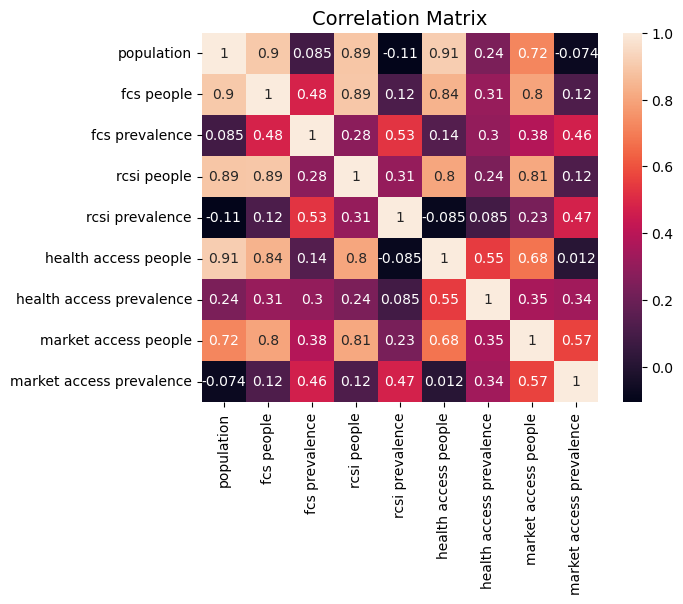

✓ Correlation matrix displayed

[INDICATOR 1] Temporal aggregation (grouping query)...
✓ Data aggregated by date
        date  fcs people  rcsi people  health access people  \
0 2024-01-05     8792908      6748693               2333131   
1 2024-01-06     8768623      6768154               2313100   
2 2024-01-07     8637837      6651572               2317579   
3 2024-01-08     8523043      6566154               2288343   
4 2024-01-09     8420603      6550754               2271646   

   market access people  
0               3225117  
1               3208684  
2               3262870  
3               3223801  
4               3249007  

[INDICATOR 2] Data transformations applied:
✓ KNN Imputation for missing values
✓ Modified Z-Score (MAD) for outlier detection
✓ Feature selection based on correlation analysis

[VISUALIZATIONS] Creating exploratory charts...


13:58:29 - cmdstanpy - INFO - Chain [1] start processing
13:58:29 - cmdstanpy - INFO - Chain [1] done processing



[INDICATOR 3] FORECASTING - Temporal Analysis


Last observed value: 8,456,947 people
Predicted in 30 days: 8,284,808 people
Change: -2.04%

[INDICATOR 4] SPATIAL CLUSTERING - Regional Analysis

Cluster assignments:
               adminone  cluster
0       Alaotra Mangoro       -1
4                Androy       -1
5                 Anosy       -1
6      Atsimo Andrefana       -1
12                Diana       -1
16               Melaky        0
9             Betsiboka        0
11            Bongolava        0
15                Itasy        1
2            Analamanga        1
3          Analanjirofo        1
8            Atsinanana        2
19                Sofia        2
20       Vakinankaratra        2
18                 Sava        2
13      Haute Matsiatra        3
14             Ihorombe        3
1        Amoron I Mania        3
10                Boeny        4
17               Menabe        4
7     Atsimo Atsinanana        5
21  Vatovavy Fitovinany        5



-----

STEP 9: Pattern Mining - Association Rules
Frequent Itemsets:
 Empty DataFrame
Columns: [support, itemsets]
Index: []
Empty DataFrame
Columns: [support, itemsets]
Index: []

No frequent itemsets found. Which means that there are nor patterns; nor association rules to visualize.


In [140]:
# ============================================
# MAIN BLOCK
# ============================================
if __name__ == "__main__":
    
    print("="*60)
    print("WFP HUNGERMAP - MADAGASCAR ANALYSIS")
    print("="*60)
    
    # ============================================
    # STEP 1: DATA COLLECTION
    # ============================================
    print("\n[STEP 1] Loading data...")
    file_path = "wfp-hungermap-data-for-mdg.csv"
    df = load_data(file_path)          
    print(f"✓ Data loaded: {df.shape[0]} rows, {df.shape[1]} columns")
    
    # ============================================
    # STEP 2: DATA CLEANING & PREPROCESSING
    # ============================================
    print("\n[STEP 2] Data cleaning and preprocessing...")
    
    # Convertir les types + supprimer countrycode / datatype / countryname
    df = convert_types(df)             
    print("✓ Data types converted")
    
    # Compléter population avec FCS people / FCS prevalence
    df = fulfill_population(df)       
    print("✓ Population calculated from FCS data")
    
    # Imputation KNN sur population
    df = replace_NaN(df, ["population"])   
    print("✓ NaN values imputed with KNN")
    
    # Conversion de la colonne date
    df = transform_datetime(df, "date")   
    print("✓ Dates converted to datetime format")
    
    # Suppression de la date isolée 2023-12-04
    df = drop_outliers(df, "date", [pd.Timestamp("2023-12-04")])  
    print("✓ Outlier date removed")
    
    # Drop des NaN restants
    df.dropna(inplace=True)
    
    # Supprimer adminlevel si présent 
    if "adminlevel" in df.columns:
        df.drop(columns=["adminlevel"], inplace=True)
    
    print(f"✓ Cleaned data: {df.shape[0]} rows, {df.shape[1]} columns")

    df2 = df.copy()
    
    # ============================================
    # STEP 3: EXPLORATORY DATA ANALYSIS
    # ============================================
    print("\n[STEP 3] Exploratory Data Analysis...")
    plot_correlation_matrix(df)         
    print("✓ Correlation matrix displayed")
    
    # ============================================
    # STEP 4: INDICATOR 1 - GROUPING QUERY
    # ============================================
    print("\n[INDICATOR 1] Temporal aggregation (grouping query)...")
    
    aggdict = {
        "fcs people": "sum",
        "rcsi people": "sum",
        "health access people": "sum",
        "market access people": "sum",
    }
    popul_grouped = aggregate_by_date(df, "date", aggdict)   
    print("✓ Data aggregated by date")
    print(popul_grouped.head())
    
    # ============================================
    # STEP 5: INDICATOR 2 - DATA TRANSFORMATIONS
    # ============================================
    print("\n[INDICATOR 2] Data transformations applied:")
    print("✓ KNN Imputation for missing values")
    print("✓ Modified Z-Score (MAD) for outlier detection")
    print("✓ Feature selection based on correlation analysis")
    
    # ============================================
    # STEP 6: VISUALIZATIONS
    # ============================================
    print("\n[VISUALIZATIONS] Creating exploratory charts...")
    
    # Ligne multi-indicateurs
    fig1 = visualize_temporal_evolution(
        popul_grouped,
        "date",
        ["fcs people", "rcsi people", "health access people", "market access people"],
        "Food Security Indicators Over Time",
    )                                 
    fig1.show()
    
    # Aire FCS
    fig2 = visualize_area_chart(
        popul_grouped,
        "date",
        "fcs people",
        "Number of People with Insufficient Food Consumption",
    )                                  
    fig2.show()
    
    # Subplots 2x2
    fig3 = visualize_subplots_4indicators(
        popul_grouped,
        "date",
        ["fcs people", "rcsi people", "health access people", "market access people"],
    )                                  
    fig3.show()
    
    # Stacked bar par région
    grouped_region = aggregate_by_date_region(df, "date", "adminone", "fcs people")  
    fig4 = visualize_stacked_bar_by_region(
        grouped_region,
        "date",
        "adminone",
        "fcs people",
        "FCS People by Region Over Time",
    )                                  
    fig4.show()
    
    # Treemap snapshot
    fig5 = visualize_treemap_snapshot(
        grouped_region,
        "2024-01-05",
        "adminone",
        "fcs people",
        "FCS People by Region – 2024-01-05",
    )                                 
    fig5.show()
    
    # ============================================
    # STEP 7: INDICATOR 3 - FORECASTING
    # ============================================
    print("\n" + "="*60)
    print("[INDICATOR 3] FORECASTING - Temporal Analysis")
    print("="*60)
    
    df_prophet = prepare_for_prophet(popul_grouped, "date", "fcs people")   
    model, prediction = forecast_with_prophet(df_prophet, periods=30)       
    
    fig_forecast = visualize_forecast(df_prophet, prediction, title="FCS People Forecast")  
    fig_forecast.show()
    
    last_observed = df_prophet["y"].iloc[-1]
    last_predicted = prediction["yhat"].iloc[-1]
    change_pct = (last_predicted - last_observed) / last_observed * 100
    
    print(f"Last observed value: {last_observed:,.0f} people")
    print(f"Predicted in 30 days: {last_predicted:,.0f} people")
    print(f"Change: {change_pct:+.2f}%")
    
    # ============================================
    # STEP 8: INDICATOR 4 - SPATIAL CLUSTERING
    # ============================================
    print("\n" + "="*60)
    print("[INDICATOR 4] SPATIAL CLUSTERING - Regional Analysis")
    print("="*60)
    
    regional_data = aggregate_by_region(df, "adminone")     
    
    clustering_features = [
        "fcs prevalence",
        "rcsi prevalence",
        "health access prevalence",
        "market access prevalence",
    ]
    regional_clustered = spatial_clustering(regional_data, clustering_features)  
    
    print("\nCluster assignments:")
    print(regional_clustered[["adminone", "cluster"]].sort_values("cluster"))
    
    # Bar chart clusters
    fig_clusters_bar = visualize_clusters_bar(regional_clustered, "adminone")    
    fig_clusters_bar.show()
    
    # Scatter clusters
    fig_clusters_scatter = visualize_clusters_scatter(regional_clustered)         
    fig_clusters_scatter.show()
    
    print("\n" + "="*60)
    print("-----")
    print("="*60)

        # ============================================
    # STEP 9: Pattern Mining 
    # ============================================
    print("\n" + "="*60)
    print("STEP 9: Pattern Mining - Association Rules")
    print("="*60)

    df3 = Encoder_Transcactions(df2)

    patterns = extract_patterns(df3, min_support=0.5)

    print(patterns)



    if patterns is patterns.empty:
        ar = extract_rules(patterns)

        # Step 1: Create a list of all distinct nodes (individual items only)
        allnodes = list_nodes(ar)

        # Step 2: Create source_indices and target_indices for each rule
        source_indices, target_indices, conf_values = create_sankey_indices(ar, allnodes)

        # Verify lengths
        verify_lengths(source_indices, target_indices, conf_values)

        # Sankey diagram 
        visualize_sankey(source_indices, target_indices, conf_values, allnodes)
    else :
        print("\n"+"No frequent itemsets found. Which means that there are nor patterns; nor association rules to visualize.")


In [141]:
#!pip install dash
#!pip install jupyter-dash

WFP HUNGERMAP - MADAGASCAR ANALYSIS

[STEP 1] Loading data...
======= Load & Display Data =======



,countrycode,countryname,adminone,adminlevel,population,date,datatype,fcs people,fcs prevalence,rcsi people,rcsi prevalence,health access people,health access prevalence,market access people,market access prevalence
0,#country+code,#country+name,#adm1+name,#meta+adminlevel,#population+total,#date,#data+type,#population+fcs,#indicator+fcs+prevalence,#population+rcsi,#indicator+rcsi+prevalence,#population+health_access,#indicator+health_access+prevalence,#population+market_access,#indicator+market_access+prevalence
1,MDG,Madagascar,NaN,national,NaN,2024-03-04,SURVEY,8456947,0.32215332807656305,7816509,0.2977569119407755,2155430,0.08210751797908643,3180077,0.12113974014886676
2,MDG,Madagascar,NaN,national,NaN,2024-03-03,SURVEY,8604019,0.32775579126651516,7708249,0.2936329211224791,2185552,0.08325496662992705,3222276,0.1227472490461335
3,MDG,Madagascar,NaN,national,NaN,2024-03-02,SURVEY,8654571,0.3296814856147151,7845463,0.29885986642190426,2227397,0.08484898329823913,3284548,0.12511939962610666
4,MDG,Madagascar,NaN,national,NaN,2024-03-01,SURVEY,8597649,0.327513141248951,7748351,0.2951605462736907,2175090,0.08285642813079001,3330646,0.12687541988738874



===skip description row===


,countrycode,countryname,adminone,adminlevel,population,date,datatype,fcs people,fcs prevalence,rcsi people,rcsi prevalence,health access people,health access prevalence,market access people,market access prevalence
0,MDG,Madagascar,NaN,national,NaN,2024-03-04,SURVEY,8456947,0.322153,7816509,0.297757,2155430,0.082108,3180077,0.121140
1,MDG,Madagascar,NaN,national,NaN,2024-03-03,SURVEY,8604019,0.327756,7708249,0.293633,2185552,0.083255,3222276,0.122747
2,MDG,Madagascar,NaN,national,NaN,2024-03-02,SURVEY,8654571,0.329681,7845463,0.298860,2227397,0.084849,3284548,0.125119
3,MDG,Madagascar,NaN,national,NaN,2024-03-01,SURVEY,8597649,0.327513,7748351,0.295161,2175090,0.082856,3330646,0.126875
4,MDG,Madagascar,NaN,national,NaN,2024-02-29,SURVEY,8578497,0.326784,7827478,0.298175,2126254,0.080996,3322466,0.126564



 Data shape: (1381, 15)

======= Summary statistics =======



,population,fcs people,fcs prevalence,rcsi people,rcsi prevalence,health access people,health access prevalence,market access people,market access prevalence
count,1.320000e+03,1.381000e+03,1381.000000,1.381000e+03,1381.000000,1.381000e+03,1381.000000,1.381000e+03,1381.000000
mean,1.193241e+06,7.608201e+05,0.325185,6.230508e+05,0.275245,2.001989e+05,0.082179,2.809448e+05,0.124619
std,7.698637e+05,1.725474e+06,0.099883,1.414499e+06,0.068609,4.575622e+05,0.031464,6.369537e+05,0.055015
min,3.480530e+05,4.960400e+04,0.126463,8.473300e+04,0.081430,4.938000e+03,0.012154,2.163200e+04,0.036112
25%,8.074180e+05,1.765190e+05,0.240862,1.763340e+05,0.229417,6.330500e+04,0.055626,6.821600e+04,0.081739
50%,1.020608e+06,3.707970e+05,0.322752,2.850400e+05,0.273562,8.345200e+04,0.086711,1.295850e+05,0.116571
75%,1.498769e+06,5.642620e+05,0.413205,4.093540e+05,0.300311,1.289870e+05,0.105396,2.172740e+05,0.146769
max,4.024795e+06,9.503583e+06,0.548083,8.031839e+06,0.535283,2.573170e+06,0.184598,3.578953e+06,0.345412



======= DataFrame info =======

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1381 entries, 0 to 1380
Data columns (total 15 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   countrycode               1381 non-null   object 
 1   countryname               1381 non-null   object 
 2   adminone                  1320 non-null   object 
 3   adminlevel                1381 non-null   object 
 4   population                1320 non-null   float64
 5   date                      1381 non-null   object 
 6   datatype                  1381 non-null   object 
 7   fcs people                1381 non-null   int64  
 8   fcs prevalence            1381 non-null   float64
 9   rcsi people               1381 non-null   int64  
 10  rcsi prevalence           1381 non-null   float64
 11  health access people      1381 non-null   int64  
 12  health access prevalence  1381 non-null   float64
 13  market access people      1381

adminone                    61
adminlevel                   0
population                   0
date                         0
fcs people                   0
fcs prevalence               0
rcsi people                  0
rcsi prevalence              0
health access people         0
health access prevalence     0
market access people         0
market access prevalence     0
dtype: int64

✓ Population calculated from FCS data
✓ NaN values imputed with KNN
✓ Dates converted to datetime format
✓ Outlier date removed
✓ Cleaned data: 1320 rows, 11 columns

[STEP 3] Exploratory Data Analysis...


,population,fcs people,fcs prevalence,rcsi people,rcsi prevalence,health access people,health access prevalence,market access people,market access prevalence
population,1.000000,0.896582,0.085125,0.889291,-0.107196,0.910811,0.241089,0.722988,-0.074441
fcs people,0.896582,1.000000,0.478543,0.893831,0.117288,0.838500,0.311803,0.797661,0.121355
fcs prevalence,0.085125,0.478543,1.000000,0.279746,0.531410,0.138261,0.300098,0.383054,0.463961
rcsi people,0.889291,0.893831,0.279746,1.000000,0.306348,0.803036,0.239139,0.807435,0.117786
rcsi prevalence,-0.107196,0.117288,0.531410,0.306348,1.000000,-0.084554,0.084671,0.232223,0.472812
health access people,0.910811,0.838500,0.138261,0.803036,-0.084554,1.000000,0.547409,0.677616,0.011520
health access prevalence,0.241089,0.311803,0.300098,0.239139,0.084671,0.547409,1.000000,0.351690,0.336748
market access people,0.722988,0.797661,0.383054,0.807435,0.232223,0.677616,0.351690,1.000000,0.566557
market access prevalence,-0.074441,0.121355,0.463961,0.117786,0.472812,0.011520,0.336748,0.566557,1.000000


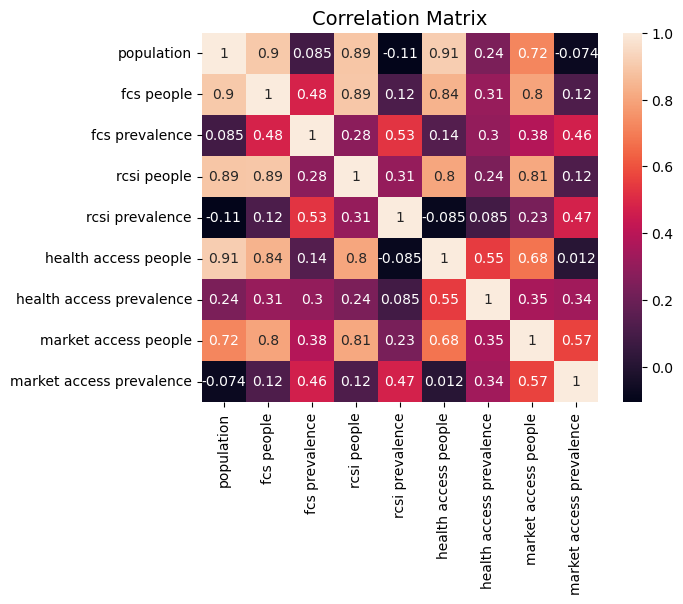


[INDICATOR 1] Temporal aggregation...

[VISUALIZATIONS] Creating exploratory charts...


13:58:30 - cmdstanpy - INFO - Chain [1] start processing



[INDICATOR 3] FORECASTING...


13:58:30 - cmdstanpy - INFO - Chain [1] done processing



[INDICATOR 4] SPATIAL CLUSTERING...

[STEP 9] Pattern Mining...
Frequent Itemsets:
 Empty DataFrame
Columns: [support, itemsets]
Index: []


In [142]:
from dash import Dash, html, dcc, jupyter_dash
import dash
from dash.dependencies import Input, Output
import plotly.graph_objects as go

# Assuming all your functions are already defined and imported
# from your_module import load_data, convert_types, etc.

# ============================================
# DATA PREPARATION (Run once)
# ============================================
def prepare_data():
    """Prepare all data for the dashboard"""
    print("="*60)
    print("WFP HUNGERMAP - MADAGASCAR ANALYSIS")
    print("="*60)
    
    # STEP 1: DATA COLLECTION
    print("\n[STEP 1] Loading data...")
    file_path = "wfp-hungermap-data-for-mdg.csv"
    df = load_data(file_path)          
    print(f"✓ Data loaded: {df.shape[0]} rows, {df.shape[1]} columns")
    
    # STEP 2: DATA CLEANING & PREPROCESSING
    print("\n[STEP 2] Data cleaning and preprocessing...")
    df = convert_types(df)             
    print("✓ Data types converted")
    
    df = fulfill_population(df)       
    print("✓ Population calculated from FCS data")
    
    df = replace_NaN(df, ["population"])   
    print("✓ NaN values imputed with KNN")
    
    df = transform_datetime(df, "date")   
    print("✓ Dates converted to datetime format")
    
    df = drop_outliers(df, "date", [pd.Timestamp("2023-12-04")])  
    print("✓ Outlier date removed")
    
    df.dropna(inplace=True)
    
    if "adminlevel" in df.columns:
        df.drop(columns=["adminlevel"], inplace=True)
    
    print(f"✓ Cleaned data: {df.shape[0]} rows, {df.shape[1]} columns")
    
    df2 = df.copy()
    
    # STEP 3: CORRELATION MATRIX
    print("\n[STEP 3] Exploratory Data Analysis...")
    fig_corr = plot_correlation_matrix(df)         
    
    # STEP 4: TEMPORAL AGGREGATION
    print("\n[INDICATOR 1] Temporal aggregation...")
    aggdict = {
        "fcs people": "sum",
        "rcsi people": "sum",
        "health access people": "sum",
        "market access people": "sum",
    }
    popul_grouped = aggregate_by_date(df, "date", aggdict)   
    
    # STEP 5: VISUALIZATIONS
    print("\n[VISUALIZATIONS] Creating exploratory charts...")
    
    fig_temporal = visualize_temporal_evolution(
        popul_grouped,
        "date",
        ["fcs people", "rcsi people", "health access people", "market access people"],
        "Food Security Indicators Over Time",
    )
    
    fig_area = visualize_area_chart(
        popul_grouped,
        "date",
        "fcs people",
        "Number of People with Insufficient Food Consumption",
    )
    
    fig_subplots = visualize_subplots_4indicators(
        popul_grouped,
        "date",
        ["fcs people", "rcsi people", "health access people", "market access people"],
    )
    
    grouped_region = aggregate_by_date_region(df, "date", "adminone", "fcs people")  
    fig_stacked = visualize_stacked_bar_by_region(
        grouped_region,
        "date",
        "adminone",
        "fcs people",
        "FCS People by Region Over Time",
    )
    
    fig_treemap = visualize_treemap_snapshot(
        grouped_region,
        "2024-01-05",
        "adminone",
        "fcs people",
        "FCS People by Region – 2024-01-05",
    )
    
    # STEP 6: FORECASTING
    print("\n[INDICATOR 3] FORECASTING...")
    df_prophet = prepare_for_prophet(popul_grouped, "date", "fcs people")   
    model, prediction = forecast_with_prophet(df_prophet, periods=30)       
    
    fig_forecast = visualize_forecast(df_prophet, prediction, title="FCS People Forecast")
    
    last_observed = df_prophet["y"].iloc[-1]
    last_predicted = prediction["yhat"].iloc[-1]
    change_pct = (last_predicted - last_observed) / last_observed * 100
    
    forecast_stats = {
        'last_observed': last_observed,
        'last_predicted': last_predicted,
        'change_pct': change_pct
    }
    
    # STEP 7: SPATIAL CLUSTERING
    print("\n[INDICATOR 4] SPATIAL CLUSTERING...")
    regional_data = aggregate_by_region(df, "adminone")     
    
    clustering_features = [
        "fcs prevalence",
        "rcsi prevalence",
        "health access prevalence",
        "market access prevalence",
    ]
    regional_clustered = spatial_clustering(regional_data, clustering_features)  
    
    fig_clusters_bar = visualize_clusters_bar(regional_clustered, "adminone")    
    fig_clusters_scatter = visualize_clusters_scatter(regional_clustered)
    
    # STEP 8: PATTERN MINING
    print("\n[STEP 9] Pattern Mining...")
    df3 = Encoder_Transcactions(df2)
    patterns = extract_patterns(df3, min_support=0.5)
    
    fig_sankey = None
    if not patterns.empty:
        ar = extract_rules(patterns)
        allnodes = list_nodes(ar)
        source_indices, target_indices, conf_values = create_sankey_indices(ar, allnodes)
        fig_sankey = visualize_sankey(source_indices, target_indices, conf_values, allnodes)
    
    return {
        'fig_corr': fig_corr,
        'fig_temporal': fig_temporal,
        'fig_area': fig_area,
        'fig_subplots': fig_subplots,
        'fig_stacked': fig_stacked,
        'fig_treemap': fig_treemap,
        'fig_forecast': fig_forecast,
        'forecast_stats': forecast_stats,
        'fig_clusters_bar': fig_clusters_bar,
        'fig_clusters_scatter': fig_clusters_scatter,
        'fig_sankey': fig_sankey,
        'regional_clustered': regional_clustered
    }


# ============================================
# PREPARE DATA
# ============================================
data_dict = prepare_data()

# ============================================
# DASH APP INITIALIZATION
# ============================================
jupyter_dash.default_mode = "external"
external_stylesheets = ['https://codepen.io/chriddyp/pen/bWLwgP.css']
app = dash.Dash( __name__ , external_stylesheets = external_stylesheets )

# ============================================
# DASHBOARD LAYOUT
# ============================================
app.layout = html.Div([
    # Header
    html.Div([
        html.H1('WFP HungerMap - Madagascar Analysis Dashboard', 
                style={'color': '#0077B6', 'textAlign': 'center', 'marginBottom': 10}),
        html.H3('Food Security Indicators and Spatial Analysis', 
                style={'color': '#023E8A', 'textAlign': 'center', 'marginTop': 0}),
        html.Hr(),
    ], style={'backgroundColor': '#CAF0F8', 'padding': '20px', 'marginBottom': '20px'}),
    
    # Section 1: Exploratory Data Analysis
    html.Div([
        html.H2('📊 Exploratory Data Analysis', style={'color': '#03045E'}),
        html.Div([
            html.Div([
                html.H4('Correlation Matrix'),
                dcc.Graph(id='graph-correlation', figure=data_dict['fig_corr']),
            ], className='six columns'),
            
            html.Div([
                html.H4('Temporal Evolution - All Indicators'),
                dcc.Graph(id='graph-temporal', figure=data_dict['fig_temporal']),
            ], className='six columns'),
        ], className='row'),
    ], style={'marginBottom': '30px'}),
    
    html.Hr(),
    
    # Section 2: Food Consumption Score (FCS) Analysis
    html.Div([
        html.H2('🍽️ Food Consumption Score (FCS) Analysis', style={'color': '#03045E'}),
        html.Div([
            html.Div([
                html.H4('FCS People Over Time (Area Chart)'),
                dcc.Graph(id='graph-area', figure=data_dict['fig_area']),
            ], className='six columns'),
            
            html.Div([
                html.H4('Four Indicators Comparison'),
                dcc.Graph(id='graph-subplots', figure=data_dict['fig_subplots']),
            ], className='six columns'),
        ], className='row'),
    ], style={'marginBottom': '30px'}),
    
    html.Hr(),
    
    # Section 3: Regional Analysis
    html.Div([
        html.H2('🗺️ Regional Analysis', style={'color': '#03045E'}),
        html.Div([
            html.Div([
                html.H4('FCS People by Region (Stacked Bar)'),
                dcc.Graph(id='graph-stacked', figure=data_dict['fig_stacked']),
            ], className='six columns'),
            
            html.Div([
                html.H4('Regional Snapshot (Treemap)'),
                dcc.Graph(id='graph-treemap', figure=data_dict['fig_treemap']),
            ], className='six columns'),
        ], className='row'),
    ], style={'marginBottom': '30px'}),
    
    html.Hr(),
    
    # Section 4: Forecasting
    html.Div([
        html.H2('🔮 Forecasting - Temporal Analysis', style={'color': '#03045E'}),
        html.Div([
            html.Div([
                html.H4('FCS People Forecast (30 Days)'),
                dcc.Graph(id='graph-forecast', figure=data_dict['fig_forecast']),
            ], className='eight columns'),
            
            html.Div([
                html.H4('Forecast Statistics'),
                html.Div([
                    html.P([
                        html.Strong('Last Observed Value: '),
                        f"{data_dict['forecast_stats']['last_observed']:,.0f} people"
                    ]),
                    html.P([
                        html.Strong('Predicted in 30 Days: '),
                        f"{data_dict['forecast_stats']['last_predicted']:,.0f} people"
                    ]),
                    html.P([
                        html.Strong('Expected Change: '),
                        html.Span(
                            f"{data_dict['forecast_stats']['change_pct']:+.2f}%",
                            style={'color': 'red' if data_dict['forecast_stats']['change_pct'] > 0 else 'green',
                                   'fontSize': '20px', 'fontWeight': 'bold'}
                        )
                    ]),
                ], style={'backgroundColor': '#F0F0F0', 'padding': '20px', 'borderRadius': '10px'})
            ], className='four columns'),
        ], className='row'),
    ], style={'marginBottom': '30px'}),
    
    html.Hr(),
    
    # Section 5: Spatial Clustering
    html.Div([
        html.H2('🎯 Spatial Clustering - Regional Analysis', style={'color': '#03045E'}),
        html.Div([
            html.Div([
                html.H4('Cluster Distribution by Region'),
                dcc.Graph(id='graph-clusters-bar', figure=data_dict['fig_clusters_bar']),
            ], className='six columns'),
            
            html.Div([
                html.H4('Cluster Visualization (Scatter)'),
                dcc.Graph(id='graph-clusters-scatter', figure=data_dict['fig_clusters_scatter']),
            ], className='six columns'),
        ], className='row'),
        
        html.Div([
            html.H4('Cluster Assignments', style={'marginTop': '20px'}),
            html.Table([
                html.Thead(html.Tr([html.Th('Region'), html.Th('Cluster')])),
                html.Tbody([
                    html.Tr([
                        html.Td(row['adminone']), 
                        html.Td(f"Cluster {row['cluster']}")
                    ]) for idx, row in data_dict['regional_clustered'].iterrows()
                ])
            ], style={'width': '100%', 'textAlign': 'center'})
        ]),
    ], style={'marginBottom': '30px'}),
    
    html.Hr(),
    
    # Section 6: Pattern Mining (conditional)
    html.Div([
        html.H2('🔗 Pattern Mining - Association Rules', style={'color': '#03045E'}),
        html.Div([
            dcc.Graph(id='graph-sankey', figure=data_dict['fig_sankey']) if data_dict['fig_sankey'] else 
            html.Div([
                html.H4('No Frequent Patterns Found', style={'textAlign': 'center', 'color': '#666'}),
                html.P('No association rules were discovered with the current minimum support threshold.',
                       style={'textAlign': 'center'})
            ], style={'padding': '50px', 'backgroundColor': '#F5F5F5', 'borderRadius': '10px'})
        ]),
    ], style={'marginBottom': '30px'}),
    
    # Footer
    html.Hr(),
    html.Div([
        html.P('© 2024 WFP HungerMap Madagascar Analysis | Data processed and visualized', 
               style={'textAlign': 'center', 'color': '#666', 'fontSize': '12px'})
    ])
])

In [143]:

# ============================================
# RUN THE APP
# ============================================
if __name__ == '__main__':
    app.run(mode="colab")

Dash app running on http://127.0.0.1:8050/
